# AnalyticGAN — Notebook 1: Exploratory Data Analysis
**Project:** Synthetic Tabular Data Generation for Privacy-Preserving Analytics  
**Dataset:** Credit Card Fraud Detection (Kaggle)  
---


## 1. Install & Import Libraries


In [33]:
# Uncomment if running on Colab
# !pip install pandas numpy matplotlib seaborn scikit-learn scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.mixture import GaussianMixture
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

print("All libraries loaded successfully.")


All libraries loaded successfully.


## 2. Load Dataset
Download from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud  
Place `creditcard.csv` in the same folder, or mount Google Drive.


In [34]:
import os
import sys
from pathlib import Path
import pkgutil
import site

import pandas as pd

# 1. Detect and show the current Python environment
print("Current Python executable:", sys.executable)

# 2. Install kagglehub into THIS environment (the notebook kernel's Python)
print("\nInstalling / upgrading kagglehub in the current environment...")
# This uses the same Python that Jupyter is running
get_ipython().run_line_magic("pip", "install kagglehub --upgrade")

# 3. Verify installation
print("\nVerifying kagglehub installation with pkgutil...")
installed = pkgutil.find_loader("kagglehub") is not None
print("kagglehub installed:", installed)

# 4. If not found, add user site-packages to sys.path and check again
if not installed:
    user_site = site.getusersitepackages()
    print("Adding user site-packages to sys.path:", user_site)
    if user_site not in sys.path:
        sys.path.append(user_site)

    installed = pkgutil.find_loader("kagglehub") is not None
    print("kagglehub installed after adding user site-packages:", installed)

    if not installed:
        raise ModuleNotFoundError(
            "kagglehub could not be found in the current Python environment.\n"
            f"Python executable: {sys.executable}\n"
            f"user site-packages: {user_site}\n"
            "Make sure Jupyter is using the same environment where kagglehub is installed."
        )

# 5. Import kagglehub and download the dataset
import kagglehub  # type: ignore

print("\nDownloading 'mlg-ulb/creditcardfraud' via kagglehub...")
dataset_dir = Path(kagglehub.dataset_download("mlg-ulb/creditcardfraud")).resolve()
print("Dataset path:", dataset_dir)

# 6. Locate creditcard.csv and load it with pandas
print("\nSearching for 'creditcard.csv' in the dataset directory...")
csv_candidates = list(dataset_dir.rglob("creditcard.csv"))

if not csv_candidates:
    print("\nFiles found in dataset directory:")
    for p in dataset_dir.rglob("*"):
        if p.is_file():
            print(" -", p.relative_to(dataset_dir))
    raise FileNotFoundError(
        f"'creditcard.csv' was not found anywhere under:\n  {dataset_dir}\n"
        "Check the file listing above to see what was downloaded."
    )

csv_path = csv_candidates[0]
print(f"Found 'creditcard.csv' at: {csv_path}")

df = pd.read_csv(csv_path)
print(f"\nDataset loaded successfully. Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

df.head()


Current Python executable: c:\ProgramData\anaconda3\python.exe

Installing / upgrading kagglehub in the current environment...


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.

Verifying kagglehub installation with pkgutil...
kagglehub installed: True



100%|██████████| 66.0M/66.0M [00:01<00:00, 45.6MB/s]

Extracting files...


Dataset path: C:\Users\Owner\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3

Searching for 'creditcard.csv' in the dataset directory...
Found 'creditcard.csv' at: C:\Users\Owner\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3\creditcard.csv

Dataset loaded successfully. Shape: 284,807 rows × 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Basic Dataset Profile


In [35]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Rows       : {df.shape[0]:,}")
print(f"Columns    : {df.shape[1]}")
print(f"Memory     : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print(f"Duplicates : {df.duplicated().sum()}")
print(f"Missing    : {df.isnull().sum().sum()}")


DATASET OVERVIEW
Rows       : 284,807
Columns    : 31
Memory     : 70.63 MB
Duplicates : 1081
Missing    : 0


In [36]:
profile = pd.DataFrame({
    "dtype"  : df.dtypes,
    "nulls"  : df.isnull().sum(),
    "unique" : df.nunique(),
    "min"    : df.min(),
    "max"    : df.max(),
    "mean"   : df.mean(numeric_only=True),
    "std"    : df.std(numeric_only=True),
})
profile


,dtype,nulls,unique,min,max,mean,std
Time,float64,0,124592,0.000000,172792.000000,9.481386e+04,47488.145955
V1,float64,0,275663,-56.407510,2.454930,1.175161e-15,1.958696
V2,float64,0,275663,-72.715728,22.057729,3.384974e-16,1.651309
V3,float64,0,275663,-48.325589,9.382558,-1.379537e-15,1.516255
V4,float64,0,275663,-5.683171,16.875344,2.094852e-15,1.415869
V5,float64,0,275663,-113.743307,34.801666,1.021879e-15,1.380247
V6,float64,0,275663,-26.160506,73.301626,1.494498e-15,1.332271
V7,float64,0,275663,-43.557242,120.589494,-5.620335e-16,1.237094
V8,float64,0,275663,-73.216718,20.007208,1.149614e-16,1.194353
V9,float64,0,275663,-13.434066,15.594995,-2.414189e-15,1.098632


## 4. Class Imbalance Analysis
This is the biggest challenge — only ~0.17% of transactions are fraud.


In [37]:
class_counts = df["Class"].value_counts()
class_pct    = df["Class"].value_counts(normalize=True) * 100

print(f"Legitimate (0): {class_counts[0]:,}  ({class_pct[0]:.4f}%)")
print(f"Fraud      (1): {class_counts[1]:,}  ({class_pct[1]:.4f}%)")
print(f"Imbalance ratio: {class_counts[0] / class_counts[1]:.0f}:1")


Legitimate (0): 284,315  (99.8273%)
Fraud      (1): 492  (0.1727%)
Imbalance ratio: 578:1


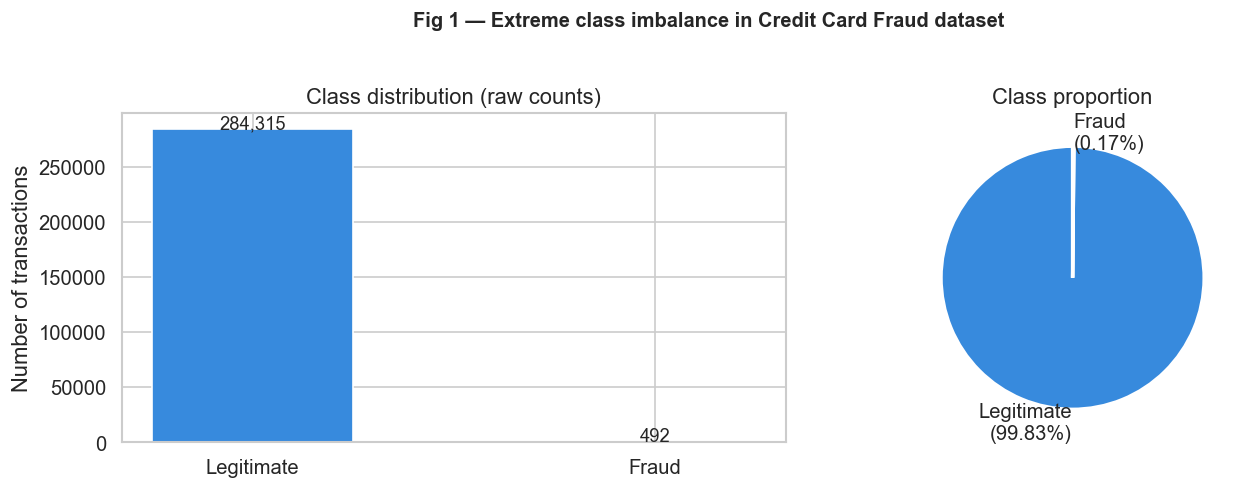

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["Legitimate", "Fraud"], class_counts.values,
            color=["#378ADD", "#D85A30"], width=0.5)
axes[0].set_title("Class distribution (raw counts)")
axes[0].set_ylabel("Number of transactions")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=11)

axes[1].pie(class_counts.values,
            labels=["Legitimate\n(99.83%)", "Fraud\n(0.17%)"],
            colors=["#378ADD", "#D85A30"],
            startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Class proportion")

plt.suptitle("Fig 1 — Extreme class imbalance in Credit Card Fraud dataset",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig1_class_imbalance.png", bbox_inches="tight")
plt.show()


## 5. Feature Distributions
V1–V28 are PCA-transformed. `Amount` and `Time` are the only raw features.


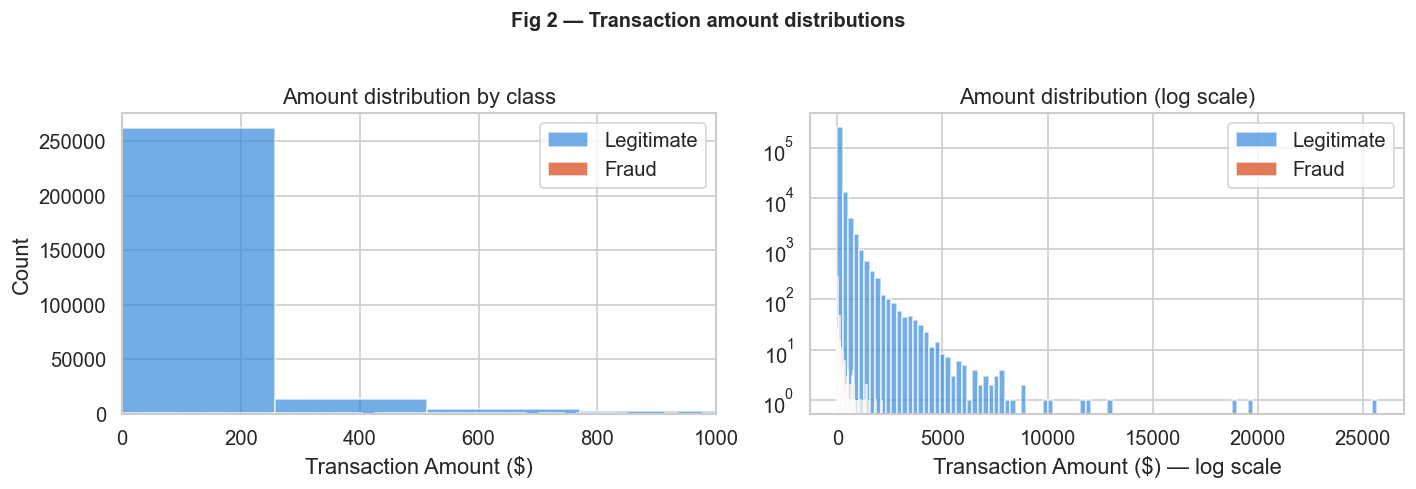

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[df["Class"] == 0]["Amount"], bins=100,
             color="#378ADD", alpha=0.7, label="Legitimate")
axes[0].hist(df[df["Class"] == 1]["Amount"], bins=100,
             color="#D85A30", alpha=0.8, label="Fraud")
axes[0].set_xlabel("Transaction Amount ($)")
axes[0].set_ylabel("Count")
axes[0].set_title("Amount distribution by class")
axes[0].set_xlim(0, 1000)
axes[0].legend()

axes[1].hist(df[df["Class"] == 0]["Amount"] + 1, bins=100,
             color="#378ADD", alpha=0.7, label="Legitimate", log=True)
axes[1].hist(df[df["Class"] == 1]["Amount"] + 1, bins=100,
             color="#D85A30", alpha=0.8, label="Fraud", log=True)
axes[1].set_xlabel("Transaction Amount ($) — log scale")
axes[1].set_title("Amount distribution (log scale)")
axes[1].legend()

plt.suptitle("Fig 2 — Transaction amount distributions",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig2_amount_distribution.png", bbox_inches="tight")
plt.show()


In [ ]:
v_cols = [f"V{i}" for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(18, 22))
axes = axes.flatten()

for i, col in enumerate(v_cols):
    sns.kdeplot(
        df[df["Class"] == 0][col],
        color="#378ADD",
        label="Legit",
        fill=True,
        alpha=0.4,
        ax=axes[i],
    )
    sns.kdeplot(
        df[df["Class"] == 1][col],
        color="#D85A30",
        label="Fraud",
        fill=True,
        alpha=0.5,
        ax=axes[i],
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_yticks([])
    axes[i].tick_params(labelsize=8)

axes[0].legend(fontsize=9)
plt.suptitle(
    "Fig 3 — KDE distributions of V1–V28 (Legit vs Fraud)",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.savefig("fig3_feature_distributions.png", bbox_inches="tight")
plt.show()


## 6. Correlation Analysis


In [ ]:
corr = df.drop(columns=["Class"]).corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0,
            linewidths=0.3, annot=False, ax=ax, vmin=-0.5, vmax=0.5)
ax.set_title("Fig 4 — Feature correlation matrix",
             fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("fig4_correlation_matrix.png", bbox_inches="tight")
plt.show()


In [ ]:
class_corr = df.corr()["Class"].drop("Class").abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
class_corr.head(15).plot(kind="barh", color="#7F77DD", ax=ax)
ax.set_xlabel("|Pearson correlation with Class|")
ax.set_title("Fig 5 — Top 15 features most correlated with fraud label")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("fig5_class_correlations.png", bbox_inches="tight")
plt.show()

print("\nTop 10 features correlated with fraud:")
print(class_corr.head(10).to_string())


## 7. Multi-Modal Distribution Check
Identify which columns need VGM encoding (multi-modal shapes).


In [ ]:
def best_n_components(series, max_k=10):
    """Select best GMM component count using BIC score."""
    X = series.dropna().values.reshape(-1, 1)
    bics = []
    for k in range(1, max_k + 1):
        gmm = GaussianMixture(n_components=k, random_state=42, max_iter=200)
        gmm.fit(X)
        bics.append((k, gmm.bic(X)))
    return min(bics, key=lambda x: x[1])[0]

sample_cols = ["Amount", "V1", "V2", "V3", "V4", "V10", "V14", "V17"]
mode_counts = {}

print(f"{'Column':<12} {'Best GMM k'}")
print("-" * 30)
for col in sample_cols:
    k = best_n_components(df[col])
    mode_counts[col] = k
    print(f"{col:<12} {k}  {'█' * k}")


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(sample_cols):
    X = df[col].values.reshape(-1, 1)
    k = mode_counts[col]
    gmm = GaussianMixture(n_components=k, random_state=42).fit(X)
    x_range = np.linspace(df[col].min(), df[col].max(), 300).reshape(-1, 1)
    logprob = gmm.score_samples(x_range)

    axes[i].hist(df[col], bins=80, density=True,
                 color="#B5D4F4", alpha=0.6, label="Data")
    axes[i].plot(x_range, np.exp(logprob),
                 color="#185FA5", linewidth=2, label=f"GMM k={k}")
    axes[i].set_title(f"{col}  (k={k} modes)")
    axes[i].legend(fontsize=8)
    axes[i].set_yticks([])

plt.suptitle("Fig 6 — GMM fits for VGM preprocessor planning",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig6_gmm_fits.png", bbox_inches="tight")
plt.show()


## 8. Key EDA Findings (Report Section 2)


In [ ]:
print("""
KEY FINDINGS — What this means for our GAN
===========================================

1. EXTREME CLASS IMBALANCE (99.83% / 0.17%)
   → Standard GAN ignores minority class entirely
   → Fix: Mode-aware conditional sampler in training

2. MULTI-MODAL CONTINUOUS DISTRIBUTIONS
   → Simple Gaussian assumption fails for many columns
   → Fix: VGM encoding captures multi-modal shapes

3. PCA-TRANSFORMED FEATURES (V1–V28)
   → Already decorrelated, but higher-order interactions exist
   → Fix: Self-attention layer in Generator captures these

4. WIDE AMOUNT RANGE ($0 — $25,691)
   → Heavy right tail, log-normal shape
   → VGM handles this without manual log transform

5. NO MISSING VALUES OR DUPLICATES
   → Clean dataset, no imputation needed
""")


In [ ]:
saved_figs = [
    "fig1_class_imbalance.png",
    "fig2_amount_distribution.png",
    "fig3_feature_distributions.png",
    "fig4_correlation_matrix.png",
    "fig5_class_correlations.png",
    "fig6_gmm_fits.png",
]

print("Figures saved to disk:")
for f in saved_figs:
    print(f"  ✓ {f}")

print("\nEDA complete. Proceed to 02_preprocess.ipynb")
